# FPL Squad Optimizer - Dashboard

This notebook uses the refactored `fpl_engine` modules to run the sequential transfer planning and optimization pipeline.

In [1]:
# Run this if you are in Google Colab to mount your drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    import sys
    sys.path.append('/content/drive/My Drive/Hobby/FPL')
except ImportError:
    pass  # Not running in Colab

Mounted at /content/drive


In [2]:
%pip install optuna optunahub
%pip install -r https://hub.optuna.org/samplers/auto_sampler/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 kB 6.7 MB/s eta 0:00:00


In [3]:
import asyncio
import pandas as pd
import nest_asyncio
nest_asyncio.apply()

from fpl_engine.config import (
    MY_FPL_ID, get_season_params,
)
from fpl_engine.data import (
    get_current_players_df, fetch_raw_history_cache,
    get_team_df, get_pos_constraint_df,
    get_current_gameweek, get_max_finished_gameweek,
    get_fpl_gameweek_data, get_my_player_ids,
    get_dynamic_weights,
)
from fpl_engine.features import (
    compute_rolling_team_ratings, blend_team_ratings,
    get_fixture_players_stats_df, compute_global_z_distributions,
)
from fpl_engine.scoring import (
    _fit_bonus_multinomial, _fit_regression_params,
    _calculate_performance_indices, create_optimized_custom_score,
)
from fpl_engine.solver import plan_sequential_transfers

## 1. Configuration

In [4]:
bank_values = 3.0
current_free_transfer_avaliable = 1
default_horizon = 6

max_diff_weight = 0.13
max_upside_weight = 0.12

current_realizable_value_dict = {
      # GKP
      139: 4.5, 736: 5.6,
      # DEF
      5: 7.0, 77: 4.0, 151: 4.5, 256: 5.8, 343: 4.2,
      # MID
      82: 8.1, 235: 10.3, 449: 9.9, 457: 5.7, 488: 6.8,
      # FWD
      100: 4.6, 311: 5.0, 430: 14.3
}


## 2. Fetch Data & Build Features

In [5]:
# 1. Fetch Base Data
current_gw = get_current_gameweek()
data_gameweek = get_max_finished_gameweek()
fpl_team_df = get_team_df()
players_df = get_current_players_df()

# 2. Season-Adaptive Params (interpolated for current GW)
params = get_season_params(current_gw)

print(f"Current Gameweek: {current_gw}")
print(f"Max Finished GW:  {data_gameweek}")

# 3. Fetch Match History (Async)
active_player_ids = players_df[players_df['minutes'] > 0]['id'].tolist()
raw_history_df = await fetch_raw_history_cache(active_player_ids, use_cache=True)

Current Gameweek: 37
Max Finished GW:  36


Fetching Match History:   0%|          | 0/532 [00:00<?, ?it/s]

Saved 18980 match records to raw_history_cache.parquet.


In [6]:
from fpl_engine.tuning import auto_tune_if_needed
from fpl_engine.config import get_season_params

# 1. Trigger the automated tuning pipeline
# Set force=True if you want to run it immediately regardless of staleness
await auto_tune_if_needed(current_gw, force=False)

# 2. Reload parameters to ensure we are using the newly tuned values
params = get_season_params(current_gw)
print("Parameters loaded and ready.")


Parameters up to date. (Last tuned GW: 37, 0d ago)
Parameters loaded and ready.


In [7]:
# 4. Compute Team Ratings & Blends
rolling_ratings_raw, latest_ratings_raw = compute_rolling_team_ratings(
    raw_history_df,
    ema_alpha    = params.get('rolling_ema_alpha', 0.15),
    min_fixtures = 3,
)

team_ratings_df, latest_team_ratings = blend_team_ratings(
    rolling_ratings_raw,
    latest_ratings_raw,
    fpl_team_df,
    league_avg_xG           = params.get('league_avg_xG',            1.45),
    league_avg_xGC          = params.get('league_avg_xGC',           1.45),
    blend_alpha             = params.get('blend_alpha',              0.75),
    min_fixtures_full_trust = params.get('min_fixtures_full_trust',  10),
)

# 5. Generate Fixture Specific Projections
global_dists = compute_global_z_distributions(team_ratings_df)

fixture_player_df = get_fixture_players_stats_df(
    params,
    raw_history_df,
    global_dists,
    team_ratings_df    = team_ratings_df,
    latest_team_ratings= latest_team_ratings,
)

/content/drive/My Drive/Hobby/FPL/fpl_engine/features.py:661: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result['is_coverage_spike'] = result['is_coverage_spike'].fillna(False).astype(bool)


## 3. Generate Scoring Projections

In [8]:
# 1. Fit Models & Inject Regression Weights
reg_params  = _fit_regression_params(fixture_player_df)
bonus_model = _fit_bonus_multinomial(raw_history_df)
params.update(reg_params)

# 2. Calculate Performance Indices
fixture_player_df = _calculate_performance_indices(
    fixture_player_df,
    params,
    bonus_model=bonus_model
)

In [9]:
# 3. Aggregate to per-GW projections (sum scoring, mean rates)
grouping_columns = [
    'gameweek', 'id_player', 'now_cost', 'selected_by_percent',
    'web_name', 'position', 'team_name'
]

sum_columns = [
    'Perf_IDX', 'ceiling_score', 'GOAL_INDEX', 'ASSIST_INDEX',
    'CLEAN_SHEET_INDEX', 'bonus_component', 'defcon_component',
    'minutes_IDX', 'actual_minutes'
]

mean_columns = [
    'recent_minutes_form', 'finishing_factor', 'protective_factor',
    'fixture_attack_multiplier', 'fixture_defence_multiplier',
    'fixture_calibrated_points',
    'start_per_gameplayed', 'consecutive_start_streak', 'hybrid_bps_abs', 'score_std',
]

# Build agg_dict: only include columns that actually exist
agg_dict = {col: 'sum' for col in sum_columns if col in fixture_player_df.columns}
agg_dict.update({col: 'mean' for col in mean_columns if col in fixture_player_df.columns})

# Only use grouping columns that exist
valid_grouping = [c for c in grouping_columns if c in fixture_player_df.columns]

gw_projection_df = fixture_player_df.groupby(valid_grouping).agg(agg_dict).reset_index()

print(f"Aggregated: {len(fixture_player_df)} fixture rows -> {len(gw_projection_df)} GW projection rows")

Aggregated: 33344 fixture rows -> 31429 GW projection rows


Mode: PUSH 🟠  (15.3% from target)  |  Diff: 0.2080  |  Upside: 0.1632

=== DYNAMIC MAPPING SUMMARY TABLE ===


,Avg_Perf_IDX,Avg_Custom_Score,Avg_Gap_Ratio,Avg_Dynamic_Upside,Avg_Score_Std,Smoothed_CV,Diff_Final_Weight
DEF,2.46,2.80,0.717,0.150,1.312,1.522,0.192
FWD,2.02,2.36,0.882,0.157,1.265,1.973,0.248
GKP,3.78,4.16,0.644,0.144,1.598,1.154,0.145
MID,2.07,2.36,0.729,0.149,1.095,1.813,0.228


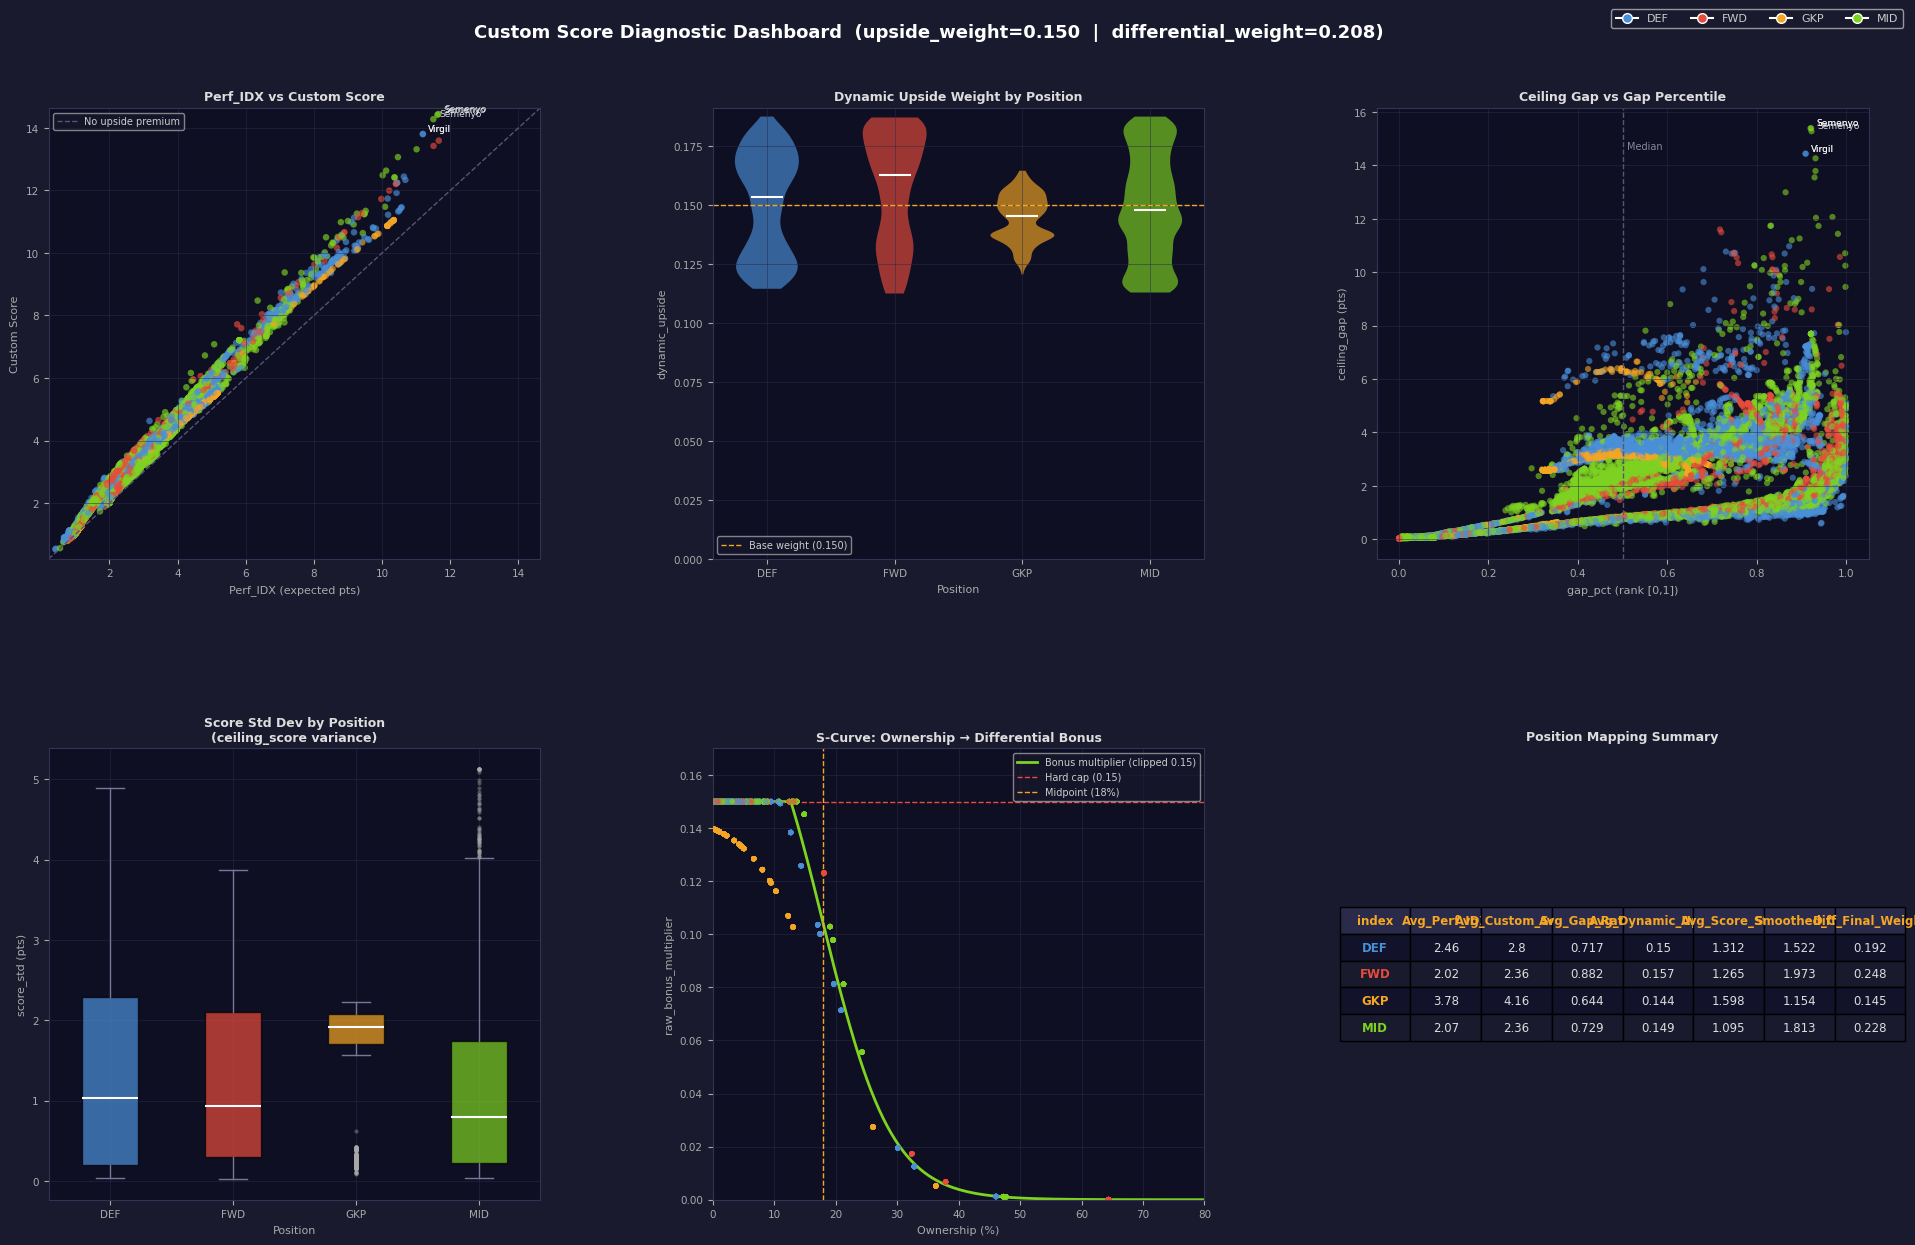

In [10]:
# 4. Dynamic Weights & Custom Score
try:
    fpl_gameweek_data = get_fpl_gameweek_data(MY_FPL_ID)
    weights = get_dynamic_weights(fpl_gameweek_data, data_gameweek,
                                  max_diff_weight=max_diff_weight,
                                  max_upside_weight=max_upside_weight)
    diff_weight   = weights['diff_weight']
    upside_weight = weights['upside_weight']
    print(f"Mode: {weights['mode']}  |  Diff: {diff_weight:.4f}  |  Upside: {upside_weight:.4f}")
except Exception as e:
    print(f"Weight fetch failed: {e} -- using max weights")
    diff_weight   = max_diff_weight
    upside_weight = max_upside_weight

gw_projection_df = create_optimized_custom_score(
    df=gw_projection_df,
    differential_weight=diff_weight,
    upside_weight=upside_weight,
    visualize=True
)

## 4. Projection Rankings

In [11]:
projection_group = ['id_player', 'now_cost', 'selected_by_percent', 'web_name',
       'position', 'team_name', ]
avg_columns = list(set(list(agg_dict.keys()) + ['custom_score', 'ceiling_score', 'dynamic_upside']))
# Only keep columns that exist
avg_columns = [c for c in avg_columns if c in gw_projection_df.columns]

display_columns = [
    'id_player', 'now_cost', 'selected_by_percent', 'web_name', 'position',
    'team_name', 'minutes_IDX', 'Perf_IDX', 'ceiling_score',
    'GOAL_INDEX', 'ASSIST_INDEX', 'CLEAN_SHEET_INDEX', 'bonus_component',
    'defcon_component', 'finishing_factor', 'fixture_attack_multiplier',
    'protective_factor', 'fixture_defence_multiplier',
]
display_columns = [c for c in display_columns if c in gw_projection_df.columns]

In [12]:
N = 15

# 1. Define the custom sorting order
pos_order = ['GKP', 'DEF', 'MID', 'FWD']

# 2. Filter and Process
top_n_df = gw_projection_df[gw_projection_df['gameweek'] >= current_gw+1].copy()
top_n_df = top_n_df.groupby(projection_group)[avg_columns].mean().reset_index()

# Convert position to a categorical type so it sorts correctly
top_n_df['position'] = pd.Categorical(top_n_df['position'], categories=pos_order, ordered=True)

# --- Safely combine columns without creating duplicates ---
final_cols = ['position', 'custom_score'] + display_columns
final_cols = list(dict.fromkeys(final_cols))
final_cols = [c for c in final_cols if c in top_n_df.columns]

# 3. Apply grouping and selection
result = (top_n_df
          .sort_values(['position', 'custom_score'], ascending=[True, False])
          .groupby('position', observed=True)
          .head(N)
          )[final_cols]

# 4. Print as a clean string
print(f"--- Top {N} Projections from GW{current_gw+1} + ---")
for pos in pos_order:
    pos_data = result[result['position'] == pos].round(3)
    print(f"\n== {pos} ==")
    if pos_data.empty:
        print("No data found.")
    else:
        print(pos_data.drop(columns=['position']).to_string(index=False))

--- Top 15 Projections from GW38 + ---

== GKP ==
 custom_score  id_player  now_cost  selected_by_percent      web_name      team_name  minutes_IDX  Perf_IDX  ceiling_score  GOAL_INDEX  ASSIST_INDEX  CLEAN_SHEET_INDEX  bonus_component  defcon_component  finishing_factor  fixture_attack_multiplier  protective_factor  fixture_defence_multiplier
        5.514        182       4.5                  0.9      Trafford       Man City       90.000     5.161          7.745       0.000         0.000              3.060            0.008               0.0             0.946                      1.035              0.997                       1.073
        5.508        812       4.0                  0.1       Ellborg     Sunderland       90.000     5.153          7.746       0.000         0.000              3.060            0.008               0.0             0.946                      1.023              0.950                       1.047
        5.504        431       4.7                  0.3      Bayi

## 5. Sequential Transfer Planner

In [13]:
MY_CURRENT_TEAM_IDS = get_my_player_ids(MY_FPL_ID, current_gw)
locked_values = sum(current_realizable_value_dict.values()) + bank_values

print(f"My Net Transfer Value : {locked_values:.1f} M")
print(f"Bank : {bank_values:.1f} M")

plan_sequential_transfers(
    gw_projection_df = gw_projection_df,
    current_team_ids = MY_CURRENT_TEAM_IDS,
    start_gameweek = current_gw + 1,
    planning_horizon = default_horizon,
    initial_free_transfers = current_free_transfer_avaliable,
    current_realizable_value_dict = current_realizable_value_dict,
    bank_balance = bank_values,

    ft_value = 1.23,
    bench_factor = 1e-4,

    objective_column = 'custom_score',
    captain_column = 'captain_idx',

    # WC_WEEK = 24,
    # FH_WEEK = 34,
    # BB_WEEK = 33,
    # TC_WEEK = 26,

    fixed_player_dict = {
        'Default':[],
    },
    banned_player_dict = {
        'Default':[183, 221, 367,126],
    },
)

Successfully fetched your team IDs for Gameweek 37:
[736, 256, 5, 151, 488, 82, 449, 235, 457, 311, 430, 139, 343, 100, 77]
My Net Transfer Value : 103.3 M
Bank : 3.0 M

--- Running Sequential Transfer Planner for GW38 ---

Optimal Sequential Transfer Plan Found!
Projected Total Utility: 67.09

==================== Plan for Gameweek 38 ====================
Free Transfers Available: 1
Transfers Made: 1 (Hits Cost: 0)

--> OUT:
 id_player web_name   team_name position  now_cost  custom_score  captain_idx  selected_by_percent  minutes_IDX  fixture_attack_multiplier  fixture_defence_multiplier  GOAL_INDEX  ASSIST_INDEX  CLEAN_SHEET_INDEX  bonus_component  defcon_component
        77     Hill Bournemouth      DEF       4.2         4.047        5.717                  7.3       83.434                      0.985                       1.035       0.073         0.112              1.146            0.003             0.756

<-- IN:
 id_player web_name team_name position  now_cost  custom_score  cap